In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# 1. Carregar o dataset
df = pd.read_csv('student_exam_data.csv')

# Exibir as primeiras linhas para confirmar a leitura
display(df.head())

# 2. Separar as entradas (Features) e a saída (Target)

X = df[['Study Hours', 'Previous Exam Score']].values

y = df[['Pass/Fail']].values

# 3. Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test)

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


Criação do DataLoader

In [4]:
# Criar o dataset do PyTorch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Criar o DataLoader com batches de 16 amostras e embaralhamento (shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Tamanho do DataLoader de Treino: {len(train_loader)} batches")

Tamanho do DataLoader de Treino: 25 batches


Definição do Modelo de Regressão Logística

In [7]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()

        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):

        return self.linear(x)

model = LogisticRegressionModel(input_dim=2)


print(model)

LogisticRegressionModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


Função de Perda (Loss), Otimizador e Laço de Treinamento

Iniciando o Treinamento...
Época [20/100], Perda: 0.2862
Época [40/100], Perda: 0.2662
Época [60/100], Perda: 0.2603
Época [80/100], Perda: 0.2580
Época [100/100], Perda: 0.2569


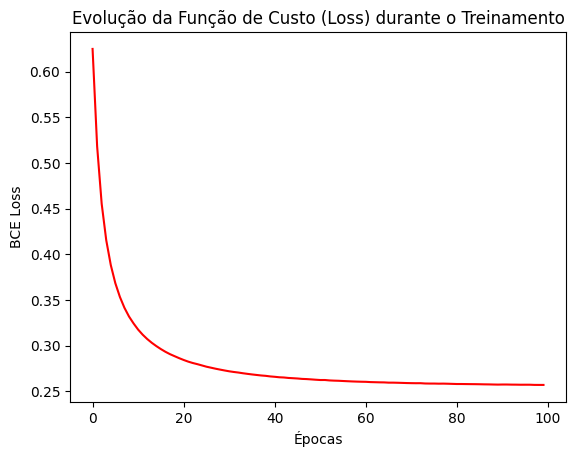

In [8]:
# Função de custo (Binary Cross Entropy with Logits)
criterion = nn.BCEWithLogitsLoss()

# Otimizador (Descida do Gradiente) com taxa de aprendizado de 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

epochs = 100
train_losses = []

print("Iniciando o Treinamento...")
for epoch in range(epochs):
    epoch_loss = 0.0

    # Iterando sobre os batches do nosso DataLoader
    for batch_X, batch_y in train_loader:

        # 1. Forward pass (Predição)
        y_pred = model(batch_X)

        # 2. Cálculo do erro (Loss)
        loss = criterion(y_pred, batch_y)

        # 3. Backward pass (Zerando gradientes, calculando novos e atualizando pesos)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Guardar a média de perda da época
    train_losses.append(epoch_loss / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f"Época [{epoch+1}/{epochs}], Perda: {train_losses[-1]:.4f}")

# Plotar gráfico da perda
plt.plot(train_losses, color='red')
plt.title("Evolução da Função de Custo (Loss) durante o Treinamento")
plt.xlabel("Épocas")
plt.ylabel("BCE Loss")
plt.show()

Avaliação e Acurácia

In [9]:
# Modo de avaliação
model.eval()

with torch.no_grad():
    # Passa os dados de teste na rede
    y_pred_test_bruto = model(X_test_tensor)

    # Aplica a função sigmóide para transformar as saídas em probabilidades (0.0 a 1.0)
    probabilidades = torch.sigmoid(y_pred_test_bruto)

    # Arredonda: Se a probabilidade for > 0.5, prevemos 1 (Passou), senão 0 (Reprovou)
    previsoes = probabilidades.round()


    acertos = (previsoes == y_test_tensor).sum().item()


    total = y_test_tensor.size(0)
    acuracia = (acertos / total) * 100

    print(f"Total de Amostras de Teste: {total}")
    print(f"Acertos: {acertos}")
    print(f"Acurácia Final: {acuracia:.2f}%")

Total de Amostras de Teste: 100
Acertos: 86
Acurácia Final: 86.00%
